In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold

In [4]:
waka_dragon_df = pd.read_csv("data/waka_dragon_merged.csv")
mX_df = waka_dragon_df.loc[:, 'MW':]

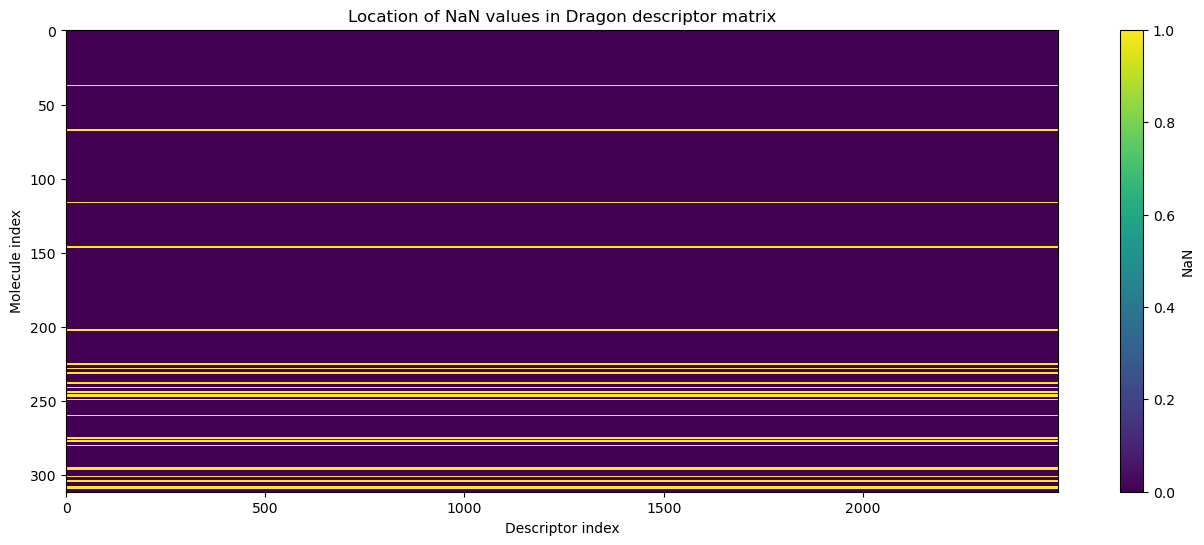

In [5]:
plt.figure(figsize=(16, 6))

plt.imshow(
    mX_df.isna(),
    aspect='auto',
    interpolation='none'
)

plt.xlabel('Descriptor index')
plt.ylabel('Molecule index')
plt.title('Location of NaN values in Dragon descriptor matrix')

plt.colorbar(label='NaN')
plt.show()

In [6]:
valid_mask = ~mX_df.isna().all(axis=1)
valid_mask

0       True
1       True
2       True
3       True
4       True
       ...  
307     True
308    False
309    False
310     True
311     True
Length: 312, dtype: bool

In [7]:
mX_df = waka_dragon_df.loc[valid_mask, 'MW':]

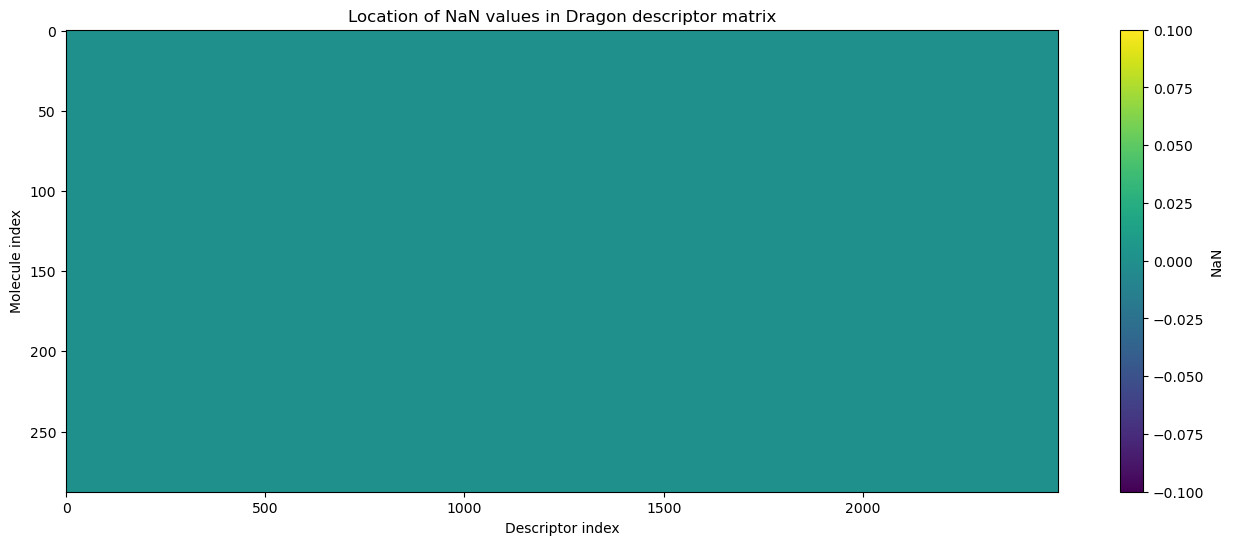

In [8]:
plt.figure(figsize=(16, 6))

plt.imshow(
    mX_df.isna(),
    aspect='auto',
    interpolation='none'
)

plt.xlabel('Descriptor index')
plt.ylabel('Molecule index')
plt.title('Location of NaN values in Dragon descriptor matrix')

plt.colorbar(label='NaN')
plt.show()

In [9]:
waka_dragon_df = waka_dragon_df.loc[valid_mask,:]
waka_dragon_df

,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,AMW,Sv,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,6.294,7.537,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,7.581,9.295,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,6.759,9.822,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,8.597,12.010,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,6.444,13.876,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,15461361,67883-79-8,cis-3-hexenyl tiglate,44.85,0.01,0.63,1,182.29,5.880,17.171,...,115.496,208.52,0.847,-3.74,-3.95,-4.00,0.0,50.0,0.036,0.0
306,16063567,141773-73-1,helvetolide,7.05,-0.75,0.22,0,284.49,5.471,27.573,...,175.508,314.03,0.838,-4.20,-4.46,-4.54,1.0,98.0,0.017,0.0
307,16070752,117933-89-8,karanal,48.88,-1.32,0.50,1,266.47,5.438,26.332,...,164.119,292.88,0.873,-4.57,-4.87,-4.97,2.0,98.0,0.016,0.0
310,44153588,113889-23-9,tricyclodecenyl butyrate,24.15,-0.51,0.11,0,220.34,6.121,20.698,...,125.021,225.98,0.930,-4.19,-4.44,-4.52,6.0,88.0,0.021,0.0


In [10]:
vY_Imax = waka_dragon_df['Imax']

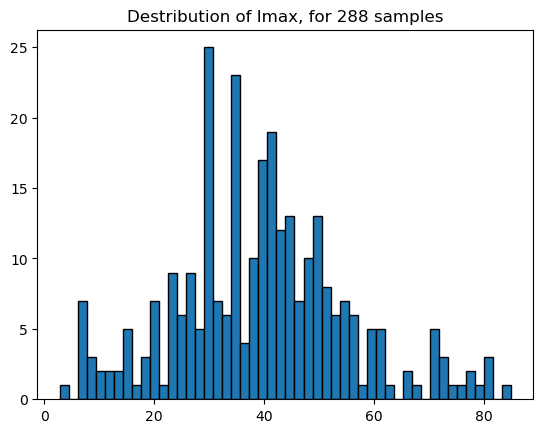

In [11]:
import matplotlib.pyplot as plt
plt.hist(vY_Imax, bins = 50, edgecolor='k')
plt.title(f"Destribution of Imax, for {len(vY_Imax)} samples")
plt.show()

In [12]:
#first we remove features with zero variance
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0) #object 

mX1 = vt.fit_transform(mX_df) #returns NDArray

# mX1_df becomes the updated feature matrix
mX1_df = pd.DataFrame(
    mX1,
    columns=mX_df.columns[vt.get_support()],
    index=mX_df.index
)

print(mX1_df.shape)

(288, 2484)


In [13]:
# correlations matrix
corr_matrix = mX1_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95) # May be the correlation threshold should be lower
]

print(f"Descriptors to remove: {len(to_drop)}")

Descriptors to remove: 1650


In [14]:
# Dropping of high correlated descriptors
mX2_df = mX1_df.drop(columns=to_drop)
print(mX2_df.shape)

(288, 834)


In [15]:
n_cols_with_nan = mX2_df.isna().any(axis=0).sum()

print(f"Columns containing NaN: {n_cols_with_nan}")
print(f"Total columns: {mX2_df.shape[1]}")

Columns containing NaN: 0
Total columns: 834


In [16]:
xgb_reg = XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_reg.fit(mX2_df, vY_Imax)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [17]:
importance = pd.Series(
    xgb_reg.feature_importances_,
    index= mX2_df.columns
).sort_values(ascending=False)

importance.head(60)

ATS6m             0.004428
Vindex            0.004106
RDF015s           0.003886
MPC08             0.003784
SpMaxA_AEA_dm_    0.003617
Eig07_AEA_dm_     0.003211
RDF065s           0.003096
SpMax6_Bh_s_      0.002788
ATS5m             0.002751
HATS0v            0.002689
SpPosA_RG         0.002679
GGI6              0.002592
Mor08m            0.002580
VE3_RG            0.002573
VE2_B_m_          0.002526
Eta_betaS_A       0.002451
SM11_AEA_bo_      0.002432
RDF010s           0.002394
H2v               0.002371
Mor03v            0.002337
SpMax7_Bh_s_      0.002310
RDF050m           0.002307
Mor11u            0.002264
ChiA_B_m_         0.002249
VE3sign_B_v_      0.002246
G2m               0.002230
SM12_AEA_bo_      0.002218
R6u               0.002209
HATS8m            0.002208
ATSC8e            0.002207
TDB01m            0.002206
SpMax2_Bh_s_      0.002196
RDF025s           0.002186
Mor05m            0.002151
ZM1Mad            0.002126
HGM               0.002105
TDB10u            0.002098
A

In [19]:
top60_reg_features = importance.index[:60]
top60_reg_features

Index(['ATS6m', 'Vindex', 'RDF015s', 'MPC08', 'SpMaxA_AEA_dm_',
       'Eig07_AEA_dm_', 'RDF065s', 'SpMax6_Bh_s_', 'ATS5m', 'HATS0v',
       'SpPosA_RG', 'GGI6', 'Mor08m', 'VE3_RG', 'VE2_B_m_', 'Eta_betaS_A',
       'SM11_AEA_bo_', 'RDF010s', 'H2v', 'Mor03v', 'SpMax7_Bh_s_', 'RDF050m',
       'Mor11u', 'ChiA_B_m_', 'VE3sign_B_v_', 'G2m', 'SM12_AEA_bo_', 'R6u',
       'HATS8m', 'ATSC8e', 'TDB01m', 'SpMax2_Bh_s_', 'RDF025s', 'Mor05m',
       'ZM1Mad', 'HGM', 'TDB10u', 'ATSC6m', 'Mor11v', 'Mor05v', 'GGI3', 'Am',
       'Mor07m', 'VE1sign_B_v_', 'R5s', 'H3u', 'AVS_B_s_', 'SpMax6_Bh_m_',
       'SM09_AEA_dm_', 'H6s', 'Mor04v', 'MATS1e', 'SpMin1_Bh_s_', 'RDF025u',
       'Mor29u', 'JGI2', 'H7s', 'ATSC1e', 'MATS1v', 'Mor13m'],
      dtype='str')

In [21]:
X_top60 = mX2_df[top60_reg_features].copy()
print(X_top60.shape)

(288, 60)


In [22]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = cross_val_score(
    xgb_reg,
    X_top60,
    vY_Imax,
    scoring="neg_mean_absolute_error",
    cv=cv
)
print("CV MAE:", -scores.mean())
print("STD:", scores.std())

CV MAE: 7.731994859061959
STD: 0.5170310748267408


In [23]:
importance = pd.Series(
    xgb_reg.feature_importances_,
    index=mX2_df.columns
).sort_values(ascending=False)

In [25]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(10, 115, 5):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,10,8.592958,0.514625
1,15,8.117381,0.563993
2,20,8.003454,0.578295
3,25,8.055779,0.574167
4,30,7.755052,0.602042
5,35,7.788903,0.596022
6,40,7.611475,0.606635
7,45,7.748365,0.595917
8,50,7.835863,0.586602
9,55,7.618073,0.607829


In [26]:
results_df.sort_values('MAE')

,n_features,MAE,R2
13,75,7.418400,0.623213
16,90,7.470724,0.618892
19,105,7.481705,0.613680
12,70,7.496842,0.616483
18,100,7.525020,0.608560
15,85,7.526849,0.615403
14,80,7.539818,0.613261
20,110,7.569502,0.609868
17,95,7.608175,0.614659
6,40,7.611475,0.606635


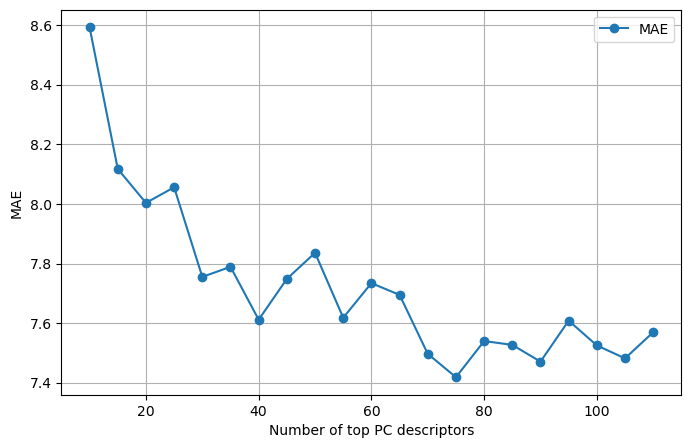

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['MAE'],
    marker='o',
    label='MAE'
)

plt.xlabel('Number of top PC descriptors')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()

plt.show()

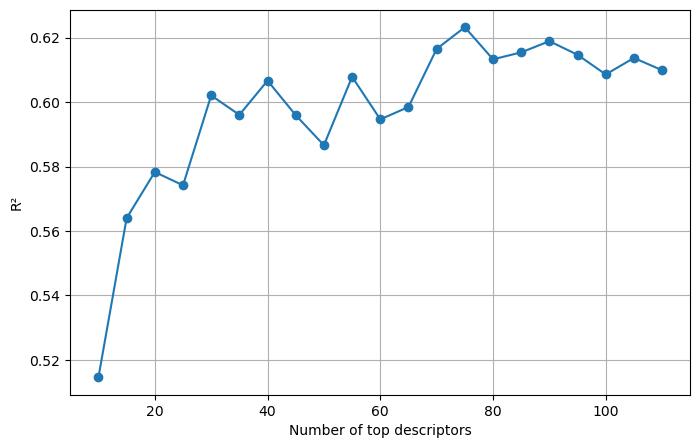

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['R2'],
    marker='o'
)

plt.xlabel('Number of top descriptors')
plt.ylabel('R²')
plt.grid(True)

plt.show()

In [31]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(60, 101, 1):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,60,7.734173,0.594628
1,61,7.623974,0.609450
2,62,7.638765,0.605556
3,63,7.595056,0.604946
4,64,7.611017,0.609802
5,65,7.694670,0.598449
6,66,7.643836,0.604867
7,67,7.605627,0.611609
8,68,7.512469,0.612409
9,69,7.610768,0.608124


In [32]:
results_df.sort_values('MAE')

,n_features,MAE,R2
11,71,7.384377,0.635358
14,74,7.414732,0.631625
15,75,7.418400,0.623213
37,97,7.426136,0.626998
18,78,7.432919,0.619904
19,79,7.433243,0.628833
13,73,7.435306,0.624355
23,83,7.455426,0.619200
34,94,7.456403,0.620659
17,77,7.456715,0.619404


In [33]:
# Fix the selected feature set
top71 = importance.index[:71]
X71 = mX2_df[top71].copy()

print(X71.shape)
print(top71)

(288, 71)
Index(['ATS6m', 'Vindex', 'RDF015s', 'MPC08', 'SpMaxA_AEA_dm_',
       'Eig07_AEA_dm_', 'RDF065s', 'SpMax6_Bh_s_', 'ATS5m', 'HATS0v',
       'SpPosA_RG', 'GGI6', 'Mor08m', 'VE3_RG', 'VE2_B_m_', 'Eta_betaS_A',
       'SM11_AEA_bo_', 'RDF010s', 'H2v', 'Mor03v', 'SpMax7_Bh_s_', 'RDF050m',
       'Mor11u', 'ChiA_B_m_', 'VE3sign_B_v_', 'G2m', 'SM12_AEA_bo_', 'R6u',
       'HATS8m', 'ATSC8e', 'TDB01m', 'SpMax2_Bh_s_', 'RDF025s', 'Mor05m',
       'ZM1Mad', 'HGM', 'TDB10u', 'ATSC6m', 'Mor11v', 'Mor05v', 'GGI3', 'Am',
       'Mor07m', 'VE1sign_B_v_', 'R5s', 'H3u', 'AVS_B_s_', 'SpMax6_Bh_m_',
       'SM09_AEA_dm_', 'H6s', 'Mor04v', 'MATS1e', 'SpMin1_Bh_s_', 'RDF025u',
       'Mor29u', 'JGI2', 'H7s', 'ATSC1e', 'MATS1v', 'Mor13m', 'HATS0p', 'VAR',
       'R6v', 'TDB06m', 'Gm', 'RDF060m', 'SsOH', 'Mor11p', 'Mor03s', 'Mor10s',
       'Mor32v'],
      dtype='str')


In [34]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_base = XGBRegressor(
    objective="reg:absoluteerror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X71, vY_Imax)

print("Best CV MAE:", -grid.best_score_)
print("Best params:")
print(grid.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best CV MAE: 7.381770465306204
Best params:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


In [35]:
best_xgb = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=4,
    n_estimators=300,
    subsample=0.8,
    random_state=42
)

In [36]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(
    best_xgb,
    X71,
    vY_Imax,
    cv=cv
)

In [37]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(vY_Imax, y_pred)
r2 = r2_score(vY_Imax, y_pred)

print(f"MAE = {mae:.3f}")
print(f"R²  = {r2:.3f}")

MAE = 7.514
R²  = 0.623


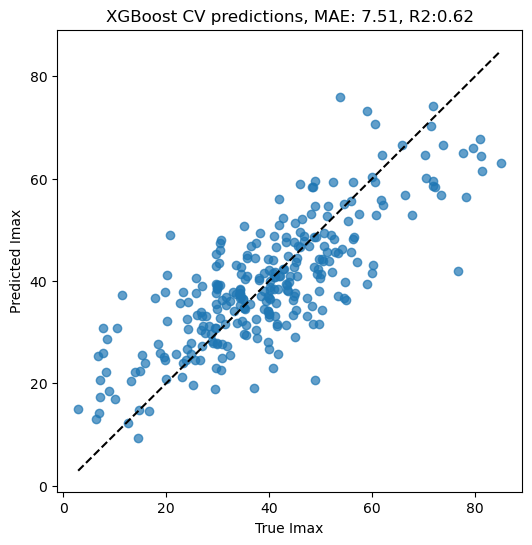

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(vY_Imax, y_pred, alpha=0.7)

plt.plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

plt.xlabel("True Imax")
plt.ylabel("Predicted Imax")
plt.title(f"XGBoost CV predictions, MAE: {mae:.2f}, R2:{r2:.2f}")

plt.show()

In [40]:
# Now, let's see how logVC influences the results
log_vp_df = pd.read_csv('data/waka_with_imputed_vp.csv')
log_vp_df = log_vp_df.loc[valid_mask,:]
merged_waka_vp = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    log_vp_df[['CID', 'log_vp']],
    on='CID',
    how='left'
)
X72 = X71.copy()
X72['log_vp'] = merged_waka_vp['log_vp']
X72

,ATS6m,Vindex,RDF015s,MPC08,SpMaxA_AEA_dm_,Eig07_AEA_dm_,RDF065s,SpMax6_Bh_s_,ATS5m,HATS0v,...,R6v,TDB06m,Gm,RDF060m,SsOH,Mor11p,Mor03s,Mor10s,Mor32v,log_vp
0,0.000,1.088,12.111,0.000,0.742,0.000,0.000,1.132,0.081,0.144,...,0.000,0.000,0.217,0.000,8.280,-0.094,-8.218,-2.686,-0.023,-0.163905
1,0.113,0.573,10.236,0.000,0.373,-1.505,0.000,1.992,1.013,0.089,...,0.009,0.008,0.351,0.051,0.000,0.208,-2.957,-1.108,-0.150,-0.001051
2,0.202,0.573,14.909,0.000,0.344,-1.350,0.000,1.992,1.110,0.141,...,0.036,0.010,0.213,0.113,8.538,0.339,-2.495,-0.503,-0.156,-1.004329
3,1.040,0.431,17.597,2.944,0.302,-0.382,0.049,3.141,1.885,0.092,...,0.050,0.084,0.338,1.033,0.000,0.123,-7.225,0.012,-0.144,-3.008774
4,1.627,0.487,16.550,0.000,0.277,-1.000,23.115,3.416,1.974,0.108,...,0.108,0.102,0.348,0.055,0.000,0.114,1.359,0.019,-0.108,-1.254028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,2.380,0.597,25.538,1.792,0.306,0.179,18.475,3.685,2.524,0.072,...,0.181,0.118,0.171,0.848,0.000,-0.228,-8.763,-0.412,0.076,NaN
306,3.338,0.390,40.240,3.135,0.185,1.118,99.222,3.895,3.565,0.052,...,0.339,0.118,0.174,7.330,0.000,-0.416,-30.526,1.995,-0.101,NaN
307,3.017,0.313,43.836,3.932,0.178,1.451,56.211,3.841,3.287,0.047,...,0.218,0.099,0.170,3.307,0.000,-0.414,-14.899,1.448,0.069,NaN
310,2.815,0.290,31.247,4.290,0.208,1.035,22.376,3.271,2.954,0.068,...,0.191,0.153,0.176,3.147,0.000,-0.435,-22.239,0.678,-0.156,NaN


In [42]:
y_pred_72 = cross_val_predict(
    best_xgb,
    X72,
    vY_Imax,
    cv=cv
)

In [43]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_72 = mean_absolute_error(vY_Imax, y_pred_72)
r2_72 = r2_score(vY_Imax, y_pred_72)

print(f"MAE = {mae_72:.3f}")
print(f"R²  = {r2_72:.3f}")

MAE = 7.502
R²  = 0.623


In [44]:
# now we try to add boiling point
bp_df = pd.read_csv('data/waka_with_imputed_bp.csv')
bp_df = bp_df.loc[valid_mask, :]
merged_waka_bp = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    bp_df[['CID', 'bp_value']],
    on='CID',
    how='left'
)
X73 = X72.copy()
X73['bp'] = merged_waka_bp['bp_value']
X73

,ATS6m,Vindex,RDF015s,MPC08,SpMaxA_AEA_dm_,Eig07_AEA_dm_,RDF065s,SpMax6_Bh_s_,ATS5m,HATS0v,...,TDB06m,Gm,RDF060m,SsOH,Mor11p,Mor03s,Mor10s,Mor32v,log_vp,bp
0,0.000,1.088,12.111,0.000,0.742,0.000,0.000,1.132,0.081,0.144,...,0.000,0.217,0.000,8.280,-0.094,-8.218,-2.686,-0.023,-0.163905,147.500000
1,0.113,0.573,10.236,0.000,0.373,-1.505,0.000,1.992,1.013,0.089,...,0.008,0.351,0.051,0.000,0.208,-2.957,-1.108,-0.150,-0.001051,178.889000
2,0.202,0.573,14.909,0.000,0.344,-1.350,0.000,1.992,1.110,0.141,...,0.010,0.213,0.113,8.538,0.339,-2.495,-0.503,-0.156,-1.004329,205.500000
3,1.040,0.431,17.597,2.944,0.302,-0.382,0.049,3.141,1.885,0.092,...,0.084,0.338,1.033,0.000,0.123,-7.225,0.012,-0.144,-3.008774,299.000000
4,1.627,0.487,16.550,0.000,0.277,-1.000,23.115,3.416,1.974,0.108,...,0.102,0.348,0.055,0.000,0.114,1.359,0.019,-0.108,-1.254028,153.796459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,2.380,0.597,25.538,1.792,0.306,0.179,18.475,3.685,2.524,0.072,...,0.118,0.171,0.848,0.000,-0.228,-8.763,-0.412,0.076,NaN,NaN
306,3.338,0.390,40.240,3.135,0.185,1.118,99.222,3.895,3.565,0.052,...,0.118,0.174,7.330,0.000,-0.416,-30.526,1.995,-0.101,NaN,NaN
307,3.017,0.313,43.836,3.932,0.178,1.451,56.211,3.841,3.287,0.047,...,0.099,0.170,3.307,0.000,-0.414,-14.899,1.448,0.069,NaN,NaN
310,2.815,0.290,31.247,4.290,0.208,1.035,22.376,3.271,2.954,0.068,...,0.153,0.176,3.147,0.000,-0.435,-22.239,0.678,-0.156,NaN,NaN


In [46]:
y_pred_73 = cross_val_predict(
    best_xgb,
    X73,
    vY_Imax,
    cv=cv
)

In [47]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_73 = mean_absolute_error(vY_Imax, y_pred_73)
r2_73 = r2_score(vY_Imax, y_pred_73)

print(f"MAE = {mae_73:.3f}")
print(f"R²  = {r2_73:.3f}")

MAE = 7.661
R²  = 0.612


In [48]:
print(
    (waka_dragon_df['CID'].values ==
     merged_waka_bp['CID'].values).all()
)

True


In [49]:
merged_waka_bp['bp_value'].corr(
    merged_waka_vp['log_vp']
)

np.float64(-0.7466852239427975)

In [50]:
importance_vp = pd.Series(
    best_xgb.fit(X72, vY_Imax).feature_importances_,
    index=X72.columns
).sort_values(ascending=False)

print(importance_vp.head(20))

ZM1Mad            0.023583
SpMaxA_AEA_dm_    0.018853
Mor08m            0.018153
ATSC8e            0.017320
ATSC6m            0.017046
R6v               0.016094
MATS1e            0.015989
Mor11p            0.015784
GGI3              0.015671
AVS_B_s_          0.015530
VE3sign_B_v_      0.015491
H7s               0.015410
SpMax6_Bh_s_      0.015381
SpMax6_Bh_m_      0.015354
Mor05m            0.015327
Gm                0.015248
ATSC1e            0.015233
HATS0p            0.015143
ATS5m             0.014853
SpMax2_Bh_s_      0.014819
dtype: float32


In [52]:
y_pred_log_vp = cross_val_predict(
    best_xgb,
    X72[['log_vp']],
    vY_Imax,
    cv=cv
)

In [53]:
mae_log_vp = mean_absolute_error(vY_Imax, y_pred_log_vp)
r2_log_vp = r2_score(vY_Imax, y_pred_log_vp)

print(f"MAE = {mae_log_vp:.3f}")
print(f"R²  = {r2_log_vp:.3f}")

MAE = 13.476
R²  = -0.184


In [54]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    merged_waka_vp['log_vp'],
    vY_Imax
)

spearman_r, spearman_p = spearmanr(
    merged_waka_vp['log_vp'],
    vY_Imax
)

print(f"Pearson r  = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}")

Pearson r  = 0.690
Spearman r = 0.678


In [56]:
from catboost import CatBoostRegressor

In [57]:
cat_model = CatBoostRegressor(
    loss_function='MAE',
    iterations=1000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

In [58]:
y_pred_cat = cross_val_predict(
    cat_model,
    X72,
    vY_Imax,
    cv=cv
)

mae_cat = mean_absolute_error(vY_Imax, y_pred_cat)
r2_cat = r2_score(vY_Imax, y_pred_cat)

print(f"CatBoost MAE = {mae_cat:.3f}")
print(f"CatBoost R²  = {r2_cat:.3f}")

CatBoost MAE = 7.492
CatBoost R²  = 0.624


In [59]:
rd_kit_df = pd.read_csv('data/waka_rdkit_expert_features.csv')
rd_kit_df

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
308,16204527,isocyclocitral,304.474,4.8474,34.14,0.0,2.0,2.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
309,19871663,terpirosa,144.258,2.4395,20.23,1.0,1.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
310,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
rd_kit_df = rd_kit_df.loc[valid_mask, :]
rd_kit_df

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,15461361,cis-3-hexenyl tiglate,182.263,2.8521,26.30,0.0,2.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
306,16063567,helvetolide,284.440,4.3397,35.53,0.0,3.0,6.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
307,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
310,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:

merged_waka_rd_kit = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    rd_kit_df.drop(columns='Name'),
    on='CID',
    how='left'
)
merged_waka_rd_kit

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,15461361,cis-3-hexenyl tiglate,182.263,2.8521,26.30,0.0,2.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
284,16063567,helvetolide,284.440,4.3397,35.53,0.0,3.0,6.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
285,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
286,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
X_rdkit = pd.concat(
    [
        X72.reset_index(drop=True),
        merged_waka_rd_kit.drop(columns=['CID', 'Name']).reset_index(drop=True)
    ],
    axis=1
)

print(X72.shape)
print(X_rdkit.shape)

(288, 72)
(288, 92)


In [63]:
duplicate_cols = X_rdkit.columns[
    X_rdkit.columns.duplicated()
]

print(duplicate_cols)

Index([], dtype='str')


In [64]:
y_pred_rdkit = cross_val_predict(
    best_xgb,
    X_rdkit,
    vY_Imax,
    cv=cv
)

mae_rdkit = mean_absolute_error(
    vY_Imax,
    y_pred_rdkit
)

r2_rdkit = r2_score(
    vY_Imax,
    y_pred_rdkit
)

print(f"MAE = {mae_rdkit:.3f}")
print(f"R² = {r2_rdkit:.3f}")

MAE = 7.444
R² = 0.629


In [65]:
best_xgb.fit(X_rdkit, vY_Imax)

importance_rdkit = pd.Series(
    best_xgb.feature_importances_,
    index=X_rdkit.columns
).sort_values(ascending=False)

importance_rdkit.head(30)

SpMaxA_AEA_dm_          0.019124
VAR                     0.016925
MATS1e                  0.016201
ZM1Mad                  0.016173
ATSC8e                  0.015859
Mor08m                  0.015116
rdkit_HeavyAtomCount    0.015003
HGM                     0.014756
rdkit_TPSA              0.014697
Mor05m                  0.014649
has_phenol              0.014589
ATSC6m                  0.014143
Mor05v                  0.013852
Mor32v                  0.013733
Mor07m                  0.013638
H3u                     0.013597
Vindex                  0.013411
Mor11p                  0.013368
RDF025u                 0.013316
ATS5m                   0.013282
H7s                     0.013227
TDB06m                  0.013217
Mor10s                  0.013175
SpMax6_Bh_s_            0.013159
HATS0p                  0.013116
ATSC1e                  0.013062
R6v                     0.012987
AVS_B_s_                0.012917
H2v                     0.012878
JGI2                    0.012728
dtype: flo

In [66]:
rdkit_cols = [
    col for col in X_rdkit.columns
    if col.startswith('rdkit_')
    or col.startswith('has_')
]

importance_rdkit[
    importance_rdkit.index.isin(rdkit_cols)
].head(20)

rdkit_HeavyAtomCount             0.015003
rdkit_TPSA                       0.014697
has_phenol                       0.014589
rdkit_MolLogP                    0.012708
rdkit_MolWt                      0.012647
rdkit_FractionCSP3               0.012171
rdkit_NumRotatableBonds          0.011738
has_aldehyde                     0.011583
has_ketone                       0.010522
has_alpha_beta_unsat_aldehyde    0.002747
rdkit_NumHDonors                 0.000000
rdkit_NumAromaticRings           0.000000
rdkit_RingCount                  0.000000
rdkit_NumHAcceptors              0.000000
has_ester                        0.000000
has_alcohol                      0.000000
has_carboxylic_acid              0.000000
has_sulfur                       0.000000
has_nitrogen                     0.000000
has_aromatic_ring                0.000000
dtype: float32

In [67]:
xgb_rdkit_reg = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

In [68]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_rdkit_reg = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

param_grid_rdkit = {
    'max_depth': [2, 3],
    'learning_rate': [0.02, 0.03, 0.05],
    'n_estimators': [600, 800, 1000],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

grid_rdkit = GridSearchCV(
    estimator=xgb_rdkit_reg,
    param_grid=param_grid_rdkit,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rdkit.fit(X_rdkit, vY_Imax)

print("Best CV MAE:", -grid_rdkit.best_score_)
print("Best params:")
print(grid_rdkit.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV MAE: 7.36842126859006
Best params:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 800, 'subsample': 0.8}


In [69]:
best_xgb_rdkit = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=0.8,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=800,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

In [70]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_rdkit_best = cross_val_predict(
    best_xgb_rdkit,
    X_rdkit,
    vY_Imax,
    cv=cv
)

mae_rdkit_best = mean_absolute_error(vY_Imax, y_pred_rdkit_best)
r2_rdkit_best = r2_score(vY_Imax, y_pred_rdkit_best)

print(f"MAE = {mae_rdkit_best:.3f}")
print(f"R²  = {r2_rdkit_best:.3f}")

MAE = 7.497
R²  = 0.623


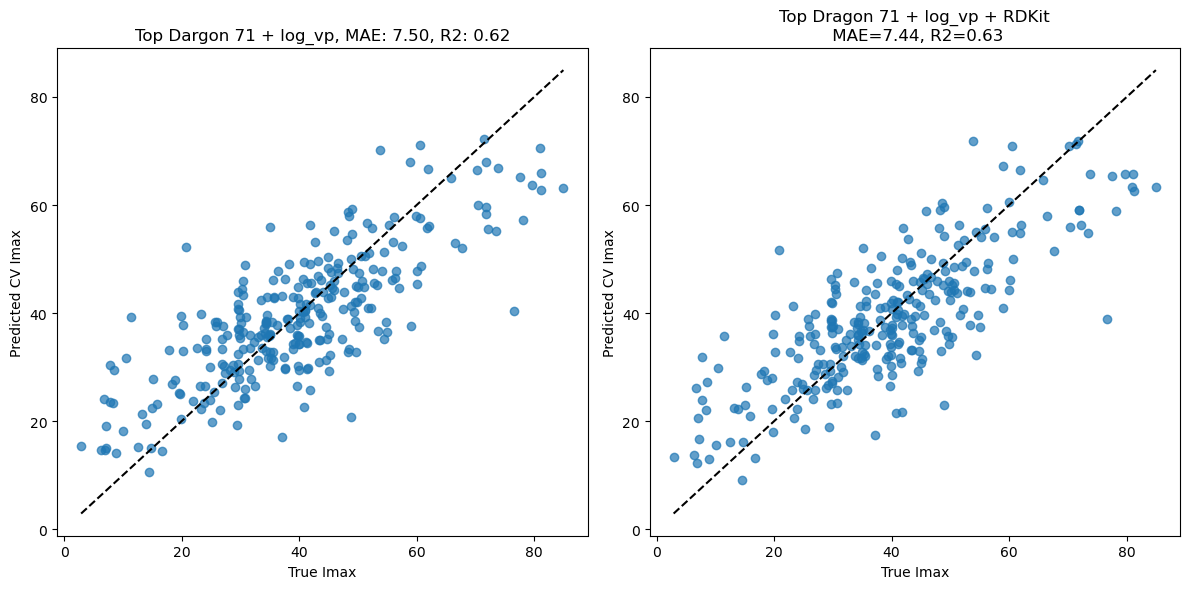

In [72]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6)
)

# Model 1
ax[0].scatter(
    vY_Imax,
    y_pred_72,
    alpha=0.7
)

ax[0].plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

ax[0].set_title(
    f'Top Dargon 71 + log_vp, MAE: {mae_72:.2f}, R2: {r2_72:.2f}'
)

ax[0].set_xlabel('True Imax')
ax[0].set_ylabel('Predicted CV Imax')

# Model 2
ax[1].scatter(
    vY_Imax,
    y_pred_rdkit_best,
    alpha=0.7
)

ax[1].plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

ax[1].set_title(
    f'Top Dragon 71 + log_vp + RDKit\n MAE={mae_rdkit:.2f}, R2={r2_rdkit:.2f}'
)

ax[1].set_xlabel('True Imax')
ax[1].set_ylabel('Predicted CV Imax')

plt.tight_layout()
plt.show()